# Choosing k

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from advisor.features import FEATURES

df = pd.read_csv(Path("../../data/processed/sleep_health.csv"))
X = StandardScaler().fit_transform(df[FEATURES])
X_distinct, counts = np.unique(X, axis=0, return_counts=True)


def fit(k, seed=42):
    return KMeans(n_clusters=k, random_state=seed, n_init=200)


figures = Path("../../figures")
figures.mkdir(exist_ok=True)
print("rows:", len(X), "| distinct rows:", len(X_distinct))

rows: 374 | distinct rows: 106


## Silhouette

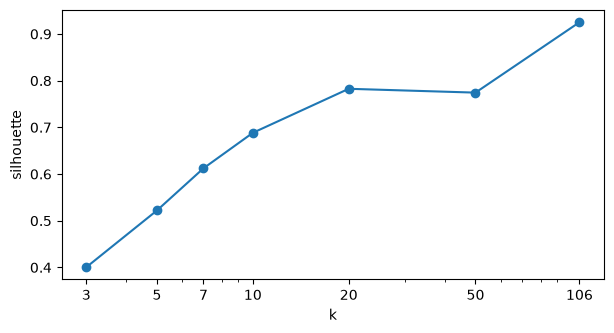

In [2]:
ks = [3, 5, 7, 10, 20, 50, 106]
scores = [silhouette_score(X, fit(k).fit_predict(X)) for k in ks]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ks, scores, marker="o")
ax.set_xscale("log")
ax.set_xticks(ks)
ax.set_xticklabels(ks)
ax.set_xlabel("k")
ax.set_ylabel("silhouette")
fig.savefig(figures / "silhouette_all_k.png", dpi=120, bbox_inches="tight")

The score keeps rising until every distinct row is its own group (106 groups, 0.93). With values on a grid it rewards small groups, so I do not use it to pick k. The elbow plot is in `clustering.ipynb` and has no clear bend either.

## Stability

Fit on a random 80% of the rows, assign all rows with that fit, compare with the fit on all rows. 50 repeats. Done on all rows and on the 106 distinct rows, so that repeated rows cannot hold a group together. The last two columns are the silhouette on the distinct rows and the same score on the distinct rows with every column shuffled (20 shuffles).

,"stability, all rows","stability, distinct rows","silhouette, distinct rows",shuffled
k,,,,
3,1.00,0.92,0.34,0.13
4,0.98,0.90,0.39,0.13
5,0.98,0.85,0.43,0.13
6,0.96,0.87,0.45,0.13
7,0.99,0.91,0.47,0.13
8,0.95,0.92,0.51,0.14


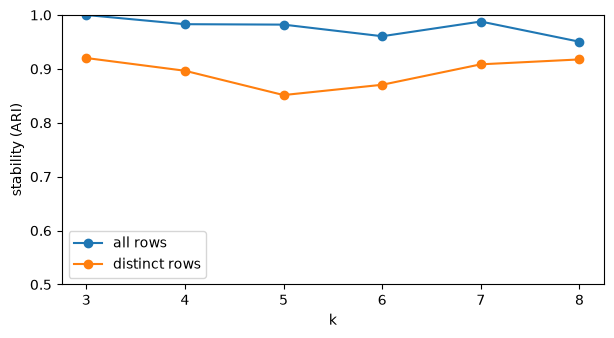

In [3]:
def stability(data, k):
    full = fit(k).fit(data)
    scores = []
    for seed in range(50):
        sample = np.random.default_rng(seed).choice(len(data), int(0.8 * len(data)), replace=False)
        scores.append(
            adjusted_rand_score(full.labels_, fit(k, seed).fit(data[sample]).predict(data))
        )
    return np.mean(scores)


rows = []
for k in range(3, 9):
    shuffled = []
    for seed in range(20):
        rng = np.random.default_rng(seed)
        data = np.column_stack([rng.permutation(X_distinct[:, j]) for j in range(X.shape[1])])
        shuffled.append(silhouette_score(data, fit(k, seed).fit_predict(data)))
    rows.append(
        {
            "k": k,
            "stability, all rows": stability(X, k),
            "stability, distinct rows": stability(X_distinct, k),
            "silhouette, distinct rows": silhouette_score(
                X_distinct, fit(k).fit(X).predict(X_distinct)
            ),
            "shuffled": np.mean(shuffled),
        }
    )
table = pd.DataFrame(rows).set_index("k")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(table.index, table["stability, all rows"], marker="o", label="all rows")
ax.plot(table.index, table["stability, distinct rows"], marker="o", label="distinct rows")
ax.set_ylim(0.5, 1)
ax.set_xlabel("k")
ax.set_ylabel("stability (ARI)")
ax.legend()
fig.savefig(figures / "stability.png", dpi=120, bbox_inches="tight")
table.round(2)

Every k is stable: 0.95 to 1.00 on all rows, 0.85 to 0.92 on the distinct rows, with no k standing out. With values on a grid and 106 patterns, any partition is easy to find again. A first version of this check, run with the default ten restarts, showed dips at k = 4 and k = 6 and peaks at 5 and 7; those were KMeans stopping at different local optima, not structure in the data (see below). So stability rules nothing out between 3 and 8 and does not pick k. The silhouette on distinct rows is 0.43 at k = 5, against 0.13 for shuffled data, so the groups are not noise; it just rises with k.

## Seeds and repeated rows

Two more checks at k = 5. First, whether different seeds give the same partition. With the default `n_init=10` only 11 seeds out of 30 reach the best solution (inertia 886); the others stop at a worse one (inertia 923) that merges half of cluster 3 into cluster 0. With 200 restarts all 30 seeds agree, so `n_init=200` is used everywhere. Second, whether the repeated rows matter: a fit on the 106 distinct rows, each weighted by how many times it appears, should give the same groups as the fit on all rows.

In [4]:
base = fit(5).fit(X)
for n_init in (10, 200):
    fits = [KMeans(n_clusters=5, random_state=seed, n_init=n_init).fit(X) for seed in range(30)]
    best = min(fits, key=lambda m: m.inertia_)
    same = sum(adjusted_rand_score(best.labels_, m.labels_) > 0.99 for m in fits)
    print(f"n_init={n_init}: {same}/30 seeds reach the best partition, inertia {best.inertia_:.0f}")

weighted = fit(5).fit(X_distinct, sample_weight=counts)
print(
    "ARI, weighted fit on distinct rows vs fit on all rows:",
    round(adjusted_rand_score(base.labels_, weighted.predict(X)), 2),
)

n_init=10: 11/30 seeds reach the best partition, inertia 886


n_init=200: 30/30 seeds reach the best partition, inertia 886
ARI, weighted fit on distinct rows vs fit on all rows: 1.0


The weighted fit gives the same partition (ARI 1.0), as it should: a repeated row and a weight are the same thing for KMeans. The unweighted stability on distinct rows above is therefore a different question, how the groups hold when every pattern counts once, not a sign that the fit on all rows is fragile.

## 5 or 7

In [5]:
k5 = fit(5).fit_predict(X)
k7 = fit(7).fit_predict(X)
pd.crosstab(k5, k7, rownames=["k = 5"], colnames=["k = 7"])

k = 7,0,1,2,3,4,5,6
k = 5,,,,,,,
0,2,61,0,38,0,0,0
1,0,0,0,0,34,0,0
2,0,0,144,1,0,0,0
3,27,0,0,0,0,35,0
4,0,0,0,0,0,0,32


In [6]:
columns = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Systolic",
    "BMI",
]
profiles = df.assign(cluster=k7).groupby("cluster")[columns].mean().round(1)
profiles["n"] = np.bincount(k7)
pd.concat([profiles, pd.crosstab(k7, df["Sleep Disorder"])], axis=1)

,Age,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level,Systolic,BMI,n,Insomnia,No disorder,Sleep Apnea
0,43.7,6.6,7.0,4.2,43.6,134.5,1.0,29,25,4,0
1,41.8,6.5,6.0,6.8,45.0,130.8,1.1,61,42,9,10
2,36.9,7.5,7.8,4.9,70.5,123.1,0.0,144,5,135,4
3,31.7,6.1,5.9,7.8,33.3,124.7,0.0,39,3,33,3
4,53.0,8.4,9.0,3.0,33.5,124.6,0.0,34,1,33,0
5,57.5,8.1,9.0,3.1,75.6,139.9,1.1,35,0,3,32
6,49.8,6.1,6.0,8.0,90.0,140.0,1.0,32,1,2,29


7 is 5 with two groups cut in two. The stressed and inactive group of 101 splits into young and healthy (39) and early forties, overweight, mostly insomnia (61). The group of 62 with good habits and a disorder splits by disorder: 27 with insomnia and 35 with apnea, the second with the highest blood pressure.

I keep k = 5. No score picks k here, so the choice is for use: each cluster becomes a short written profile for the language model, five profiles are easier to tell apart in words than seven, and the silhouette on all rows has a local peak at 5 (0.52 against 0.46 and 0.49 next to it). Each of the five has at least 32 people, though the two smallest are 8 and 9 distinct rows repeated. Whether the two extra cuts of k = 7 are worth two more profiles is something I will decide when writing the guidance.